In [1]:
# imports 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Setup Device agnostic code

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count", torch.cuda.device_count())

CUDA available: True
CUDA version: 11.8
GPU count 1


In [4]:
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "food-101"

print(f"The the datapath: {data_path}")
print(f"The image path: {image_path}")

The the datapath: data
The image path: data\food-101


### Visualize the image

In [5]:
image_path

WindowsPath('data/food-101')

data\food-101\images\pho\3090867.jpg
pho
Random image path: data\food-101\images\pho\3090867.jpg
Image class: pho
Image height: 512
Image width: 512


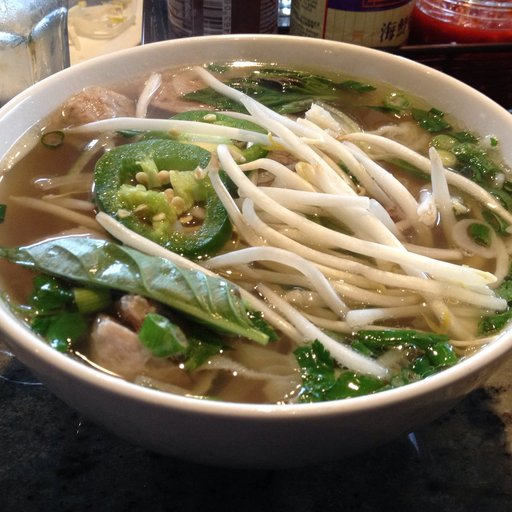

In [6]:
import random
from PIL import Image

#random.seed(42)

#1. Get all the path
image_path_list = list(image_path.glob("*/*/*.jpg"))
#print(f"Image path list : {image_path_list}")

#2. Pick a random image path 
random_image_path = random.choice(image_path_list)
print(random_image_path)

#3. get the image class (the image class is the name of the directory wheree the image is stored)
image_class  = random_image_path.parent.stem
print(image_class)

#4. Open imamge
img = Image.open(random_image_path)

#5. Print metadata of the images
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

### Tranforming the data

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Ploting the transformed images

In [8]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3585434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


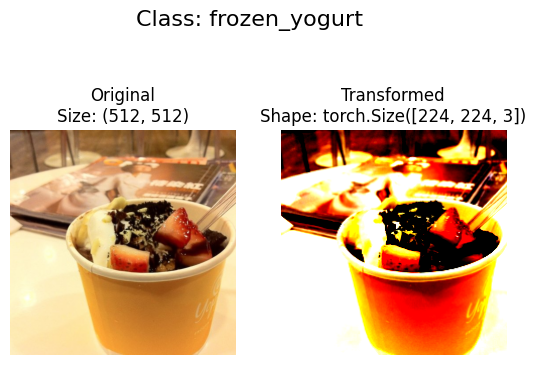

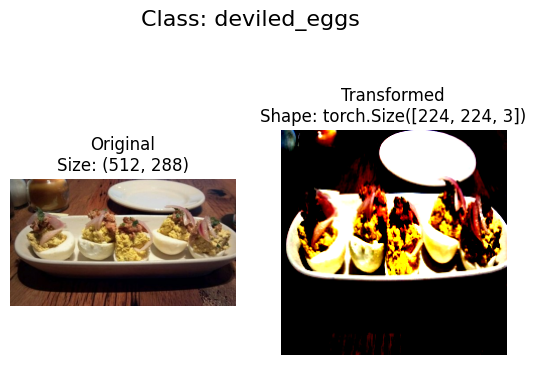

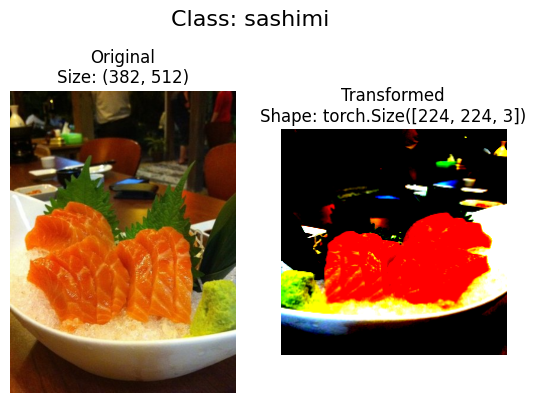

In [9]:
def plot_tranformed_images(image_paths:list,transform,n=3,seed=None):
    """ selects random images from a path of images and loads/transforms
        them then plots the original vs transformed version
    """

    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax= plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # transform and plot target image
            transformed_image = transform(f).permute(1,2,0) #Note we will need to change shape (C,H,W)->(H,W,C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}",fontsize = 16)

plot_tranformed_images(image_paths=image_path_list,
                       transform=train_transform,
                       n=3,
                       seed=None
                       )

### Load the dataset



In [10]:
train_dataset = datasets.Food101(
    root="data",
    split="train",
    transform=train_transform,
    download=False
)

test_dataset = datasets.Food101(
    root="data",
    split="test",
    transform=test_transform,
    download=False
)

In [11]:
train_dataset , test_dataset

(Dataset Food101
     Number of datapoints: 75750
     Root location: data
     split=train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset Food101
     Number of datapoints: 25250
     Root location: data
     split=test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

In [12]:
#Get class names
class_names = train_dataset.classes
len(class_names)

101

In [13]:
# class to idx
class_dict = train_dataset.class_to_idx
class_dict

{'apple_pie': 0,
 'baby_back_ribs': 1,
 'baklava': 2,
 'beef_carpaccio': 3,
 'beef_tartare': 4,
 'beet_salad': 5,
 'beignets': 6,
 'bibimbap': 7,
 'bread_pudding': 8,
 'breakfast_burrito': 9,
 'bruschetta': 10,
 'caesar_salad': 11,
 'cannoli': 12,
 'caprese_salad': 13,
 'carrot_cake': 14,
 'ceviche': 15,
 'cheese_plate': 16,
 'cheesecake': 17,
 'chicken_curry': 18,
 'chicken_quesadilla': 19,
 'chicken_wings': 20,
 'chocolate_cake': 21,
 'chocolate_mousse': 22,
 'churros': 23,
 'clam_chowder': 24,
 'club_sandwich': 25,
 'crab_cakes': 26,
 'creme_brulee': 27,
 'croque_madame': 28,
 'cup_cakes': 29,
 'deviled_eggs': 30,
 'donuts': 31,
 'dumplings': 32,
 'edamame': 33,
 'eggs_benedict': 34,
 'escargots': 35,
 'falafel': 36,
 'filet_mignon': 37,
 'fish_and_chips': 38,
 'foie_gras': 39,
 'french_fries': 40,
 'french_onion_soup': 41,
 'french_toast': 42,
 'fried_calamari': 43,
 'fried_rice': 44,
 'frozen_yogurt': 45,
 'garlic_bread': 46,
 'gnocchi': 47,
 'greek_salad': 48,
 'grilled_cheese_sa

In [14]:
# Check the length o0f our datasets
len(train_dataset),len(test_dataset)

(75750, 25250)

### Dataloaders

In [47]:
BATCH_SIZE = 128

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [48]:
train_loader,test_loader

(<torch.utils.data.dataloader.DataLoader at 0x1f746e2fc10>,
 <torch.utils.data.dataloader.DataLoader at 0x1f70b53ed10>)

In [49]:
len(train_loader)== len(train_dataset),len(test_loader)==len(test_dataset)

(False, False)

In [50]:
img,label = next(iter(train_loader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([128, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([128])


###  Create a function to display random images

1. Take in a Dataset and a number of other parameters such as classes (the names of our target classes), the number of images to display (n) and a random seed.
2. To prevent the display getting out of hand, we'll cap n at 10 images.
3. Set the random seed for reproducible plots (if seed is set).
4. Get a list of random sample indexes (we can use Python's random.sample() for this) to plot.
5. Setup a matplotlib plot.
6. Loop through the random sample indexes found in step 4 and plot them with matplotlib.
7. Make sure the sample images are of shape HWC (height, width, color channels) so we can plot them.

In [36]:
from typing import List

In [37]:
# 1.Create a function to take in a dataset
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:List[str] = None,
                          n:int = 10,
                          display_shape: bool = True,
                          seed:int = None):
    # 2. adjust the display if the n is too high
    if n>10:
        n = 10
        display_shape = False   
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    #3. setup seed
    if seed:
        random.seed(seed)

    #4. get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)),k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples 
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7069099..2.2535014].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3410363].


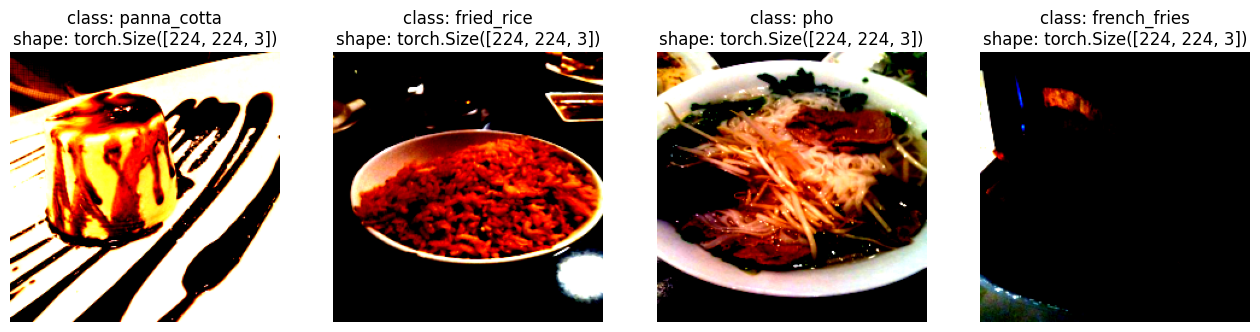

In [21]:
display_random_images(dataset=train_dataset,
                      classes=class_names,
                      n=4,
                      seed=None)

### Creating TinyVGG Model

In [38]:
class TinyVGG(nn.Module):
    def __init__(self,
                input_shape:int,
                hidden_units:int,
                output_shape:int):
        super().__init__()
        # Conv block 1
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units*2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*2,
                      out_channels=hidden_units*2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*2,
                      out_channels=hidden_units*4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*4,
                      out_channels=hidden_units*4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        # Adaptive pooling (KEY PART)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*4 * 7 * 7,
                      out_features= 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=512,
                       out_features=output_shape)
        )
    def forward(self,x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x
        #return self.classifier(self.adaptive_pool(self.block3(self.block2(self.block1(x)))))
        


In [51]:
#Initilaize models
model_VGG = TinyVGG(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)

model_VGG

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(7, 7))
  (classifier): Sequential(
    (0)

In [40]:
next(model_VGG.parameters()).device

device(type='cuda', index=0)

### Forward pass check

In [41]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_loader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_VGG.eval()
with torch.inference_mode():
    pred = model_VGG(img_single.to(device))
    
# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 224, 224])

Output logits:
tensor([[-0.0141, -0.0084,  0.0023,  0.0328, -0.0318, -0.0098, -0.0152, -0.0007,
         -0.0056, -0.0258,  0.0370, -0.0099,  0.0196,  0.0054, -0.0070,  0.0160,
         -0.0011, -0.0143,  0.0085,  0.0023, -0.0074, -0.0107, -0.0066, -0.0233,
         -0.0167, -0.0022, -0.0277, -0.0139, -0.0107,  0.0087,  0.0134,  0.0061,
         -0.0072, -0.0108, -0.0364,  0.0175,  0.0341,  0.0058,  0.0071,  0.0222,
          0.0192, -0.0198,  0.0242,  0.0316,  0.0377,  0.0394,  0.0386, -0.0189,
         -0.0020, -0.0071,  0.0232,  0.0070, -0.0311,  0.0025, -0.0083,  0.0369,
         -0.0430, -0.0137,  0.0356, -0.0362,  0.0213, -0.0420,  0.0345,  0.0042,
         -0.0012,  0.0158,  0.0372, -0.0265, -0.0351, -0.0319, -0.0267, -0.0136,
         -0.0417, -0.0067, -0.0030, -0.0183, -0.0080,  0.0411,  0.0380, -0.0159,
         -0.0229,  0.0172,  0.0213, -0.0370, -0.0089,  0.0271, -0.0003,  0.0250,
          0.0205, -0.0412, -0.0105, -0.0227,

### Parameter count

In [ ]:
total_params = sum(p.numel() for p in model_VGG.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")

Total parameters: 3550597


### create the training loop

In [58]:
def train_step(model:torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device =device):
    

    train_loss,train_acc =0,0
    model.to(device)

    model.train()

    for batch, (X,y) in enumerate(dataloader):
        X,y = X.to(device),y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)

        train_acc += (y_pred_class==y).sum().item()/len(y_pred)


    train_loss = train_loss/len(dataloader)
    train_acc = train_acc/len(dataloader)

    return train_loss,train_acc

    

In [57]:
len(train_loader)

592

### Creating test loop

In [59]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device = device):
    model.eval()

    test_loss,test_acc =0,0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            X,y = X.to(device),y.to(device)
            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits,y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)

            test_acc += (test_pred_labels==y).sum.item()/len(test_pred_labels)
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


            

### combine trainstep() and test_step()

In [60]:
from tqdm.auto import tqdm

In [61]:
def train(model:torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader:torch.utils.data.DataLoader,
          optimizer:torch.optim.Optimizer,
          epochs:int,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss()):
    
    results= {
        "train_loss":[],
        "train_acc":[],
        "test_loss":[],
        "test_acc":[]
    }

    for epoch in tqdm(range(epochs)):
        print(f"\nEpoch {epoch+1}")
        print(f"Model on : {next(model.parameters()).device}")

        train_loss,train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer)
        test_loss,test_acc =test_step(model=model,
                                      dataloader=test_dataloader,
                                      loss_fn=loss_fn)
        
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        #Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results
        

    



    

In [63]:
train_dataset.classes

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_dataset.classes)).to(device)

#next(model_0.parameters()).device

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.01)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 
model_0_results = train(model=model_0, 
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")